In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [2]:
d = pd.read_csv('../data/raw/training.csv')

In [3]:
d.info()
# d.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650698 entries, 0 to 650697
Data columns (total 8 columns):
Unnamed: 0        650698 non-null int64
contactId         650698 non-null int64
contactStart      650698 non-null object
campaignId        650698 non-null int64
abandoned         650698 non-null int64
abandonseconds    650698 non-null int64
inQueueSeconds    650698 non-null int64
agentSeconds      650698 non-null int64
dtypes: int64(7), object(1)
memory usage: 39.7+ MB


In [4]:
count = 0
for i in d['agentSeconds']:
    if i == 0:
        count = count + 1
print(f'Avg. Handle Time count of zero seconds: {count}')

Avg. Handle Time count of zero seconds: 55955


In [5]:
# d['timestamp'] = d['contactStart'].astype('datetime64[ns]')
temp_callstart = []
for i in d['contactStart'].astype('datetime64[ns]'):
    if i.minute < 30:
        lt = i.replace(minute=0, second=0, microsecond=0)
        temp_callstart.append(lt)
    elif i.minute >= 30:
        gte = i.replace(minute=30, second=0, microsecond=0)
        temp_callstart.append(gte)

d['timestamp'] = temp_callstart

In [6]:
# Query groups
call_volume = d.groupby(['timestamp'])['contactStart'].count()
avg_handle_time = d.groupby(['timestamp'])['agentSeconds'].mean()
avg_queue_time = d.groupby(['timestamp'])['inQueueSeconds'].mean()
# avg_aband_time = d.groupby(['timestamp'])['abandonseconds'].mean()

***

In [7]:
CV = [] # Call volume
for i in call_volume:
    CV.append(i)
    
AHT = []
for i in avg_handle_time:
    AHT.append(i)
    
AQT = []
for i in avg_queue_time:
    AQT.append(i)
    
# AAT = []
# for i in avg_aband_time:
#     AAT.append(i)

In [8]:
# New Dateframe
train = pd.DataFrame()
train['CV'] = CV
train['time'] = d['timestamp'].unique()
train['AHT'] = AHT
train['AQT'] = AQT
# train['AAT'] = AAT
train['minute'] = train.time.dt.minute
train['hour'] = train.time.dt.hour
train['day'] = train.time.dt.dayofweek
train['month'] = train.time.dt.month

In [9]:
train['day'].replace(5,np.NaN,inplace=True)
train['day'].replace(6,np.NaN,inplace=True)
train['day'].replace(0,'M',inplace=True)
train['day'].replace(1,'TU',inplace=True)
train['day'].replace(2,'W',inplace=True)
train['day'].replace(3,'TH',inplace=True)
train['day'].replace(4,'F',inplace=True)
# train.isnull().sum()
train.dropna(inplace=True)
train.reset_index(inplace=True, drop=True)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 8 columns):
CV        2369 non-null int64
time      2369 non-null datetime64[ns]
AHT       2369 non-null float64
AQT       2369 non-null float64
minute    2369 non-null int64
hour      2369 non-null int64
day       2369 non-null object
month     2369 non-null int64
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 148.2+ KB


***

In [11]:
count = 0
for i in train['AHT']:
    if i == 0:
        count = count + 1
print(f'Avg. Handle Time count of zero seconds: {count}')

Avg. Handle Time count of zero seconds: 526


In [12]:
train['AHT'].replace(0,np.NaN,inplace=True)
train.dropna(inplace=True)
train.reset_index(inplace=True, drop=True)

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843 entries, 0 to 1842
Data columns (total 8 columns):
CV        1843 non-null int64
time      1843 non-null datetime64[ns]
AHT       1843 non-null float64
AQT       1843 non-null float64
minute    1843 non-null int64
hour      1843 non-null int64
day       1843 non-null object
month     1843 non-null int64
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 115.3+ KB


In [14]:
train.head()

,CV,time,AHT,AQT,minute,hour,day,month
0,127,2018-05-01 07:30:00,507.692913,1.370079,30,7,TU,5
1,290,2018-05-01 08:00:00,570.900000,2.555172,0,8,TU,5
2,338,2018-05-01 08:30:00,565.769231,5.582840,30,8,TU,5
3,466,2018-05-01 09:00:00,572.927039,23.903433,0,9,TU,5
4,580,2018-05-01 09:30:00,567.168966,82.744828,30,9,TU,5


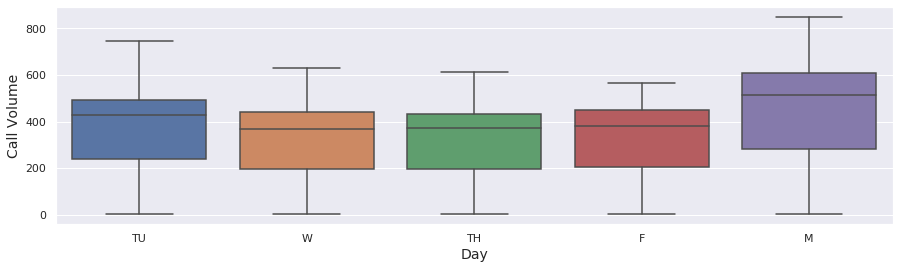

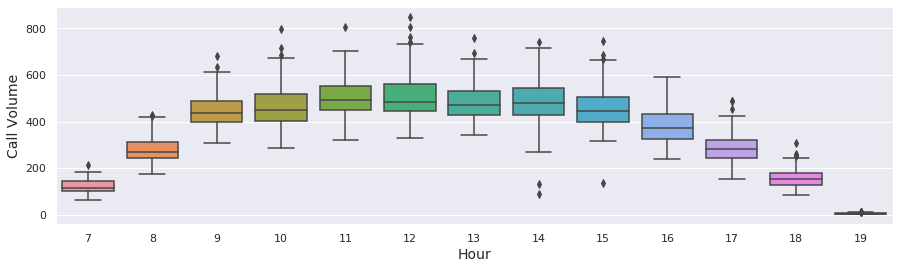

In [46]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['CV'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['CV'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Call Volume', fontsize=14)
plt.show()

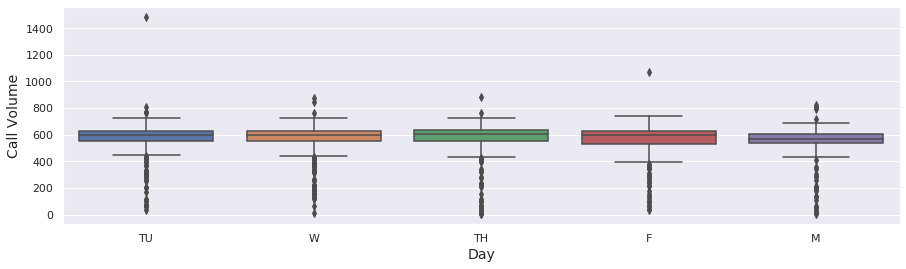

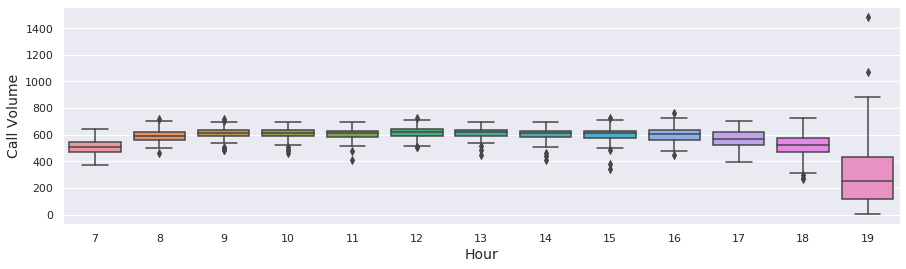

In [47]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['AHT'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['AHT'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

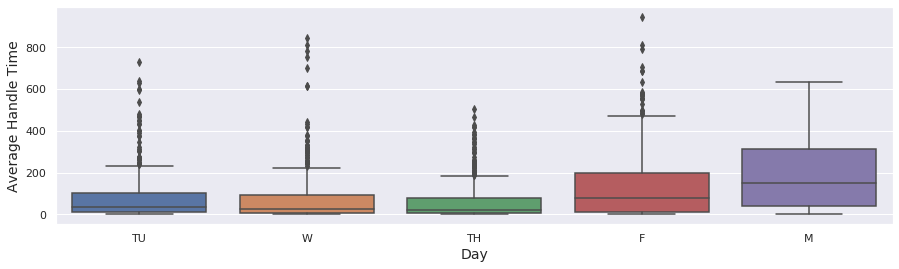

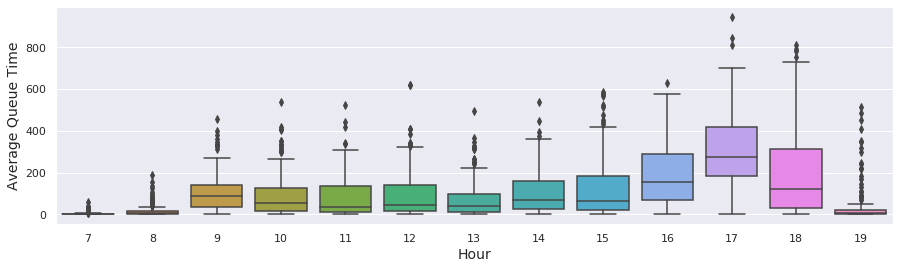

In [49]:
plt.subplots(figsize=(15, 4))
sns.boxplot(train['day'], train['AQT'])
plt.xlabel('Day', fontsize=14)
plt.ylabel('Average Handle Time', fontsize=14)
plt.show()

plt.subplots(figsize=(15, 4))
sns.boxplot(train['hour'], train['AQT'])
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Average Queue Time', fontsize=14)
plt.show()

In [16]:
train.head()

,CV,time,AHT,AQT,minute,hour,day,month
0,127,2018-05-01 07:30:00,507.692913,1.370079,30,7,TU,5
1,290,2018-05-01 08:00:00,570.900000,2.555172,0,8,TU,5
2,338,2018-05-01 08:30:00,565.769231,5.582840,30,8,TU,5
3,466,2018-05-01 09:00:00,572.927039,23.903433,0,9,TU,5
4,580,2018-05-01 09:30:00,567.168966,82.744828,30,9,TU,5


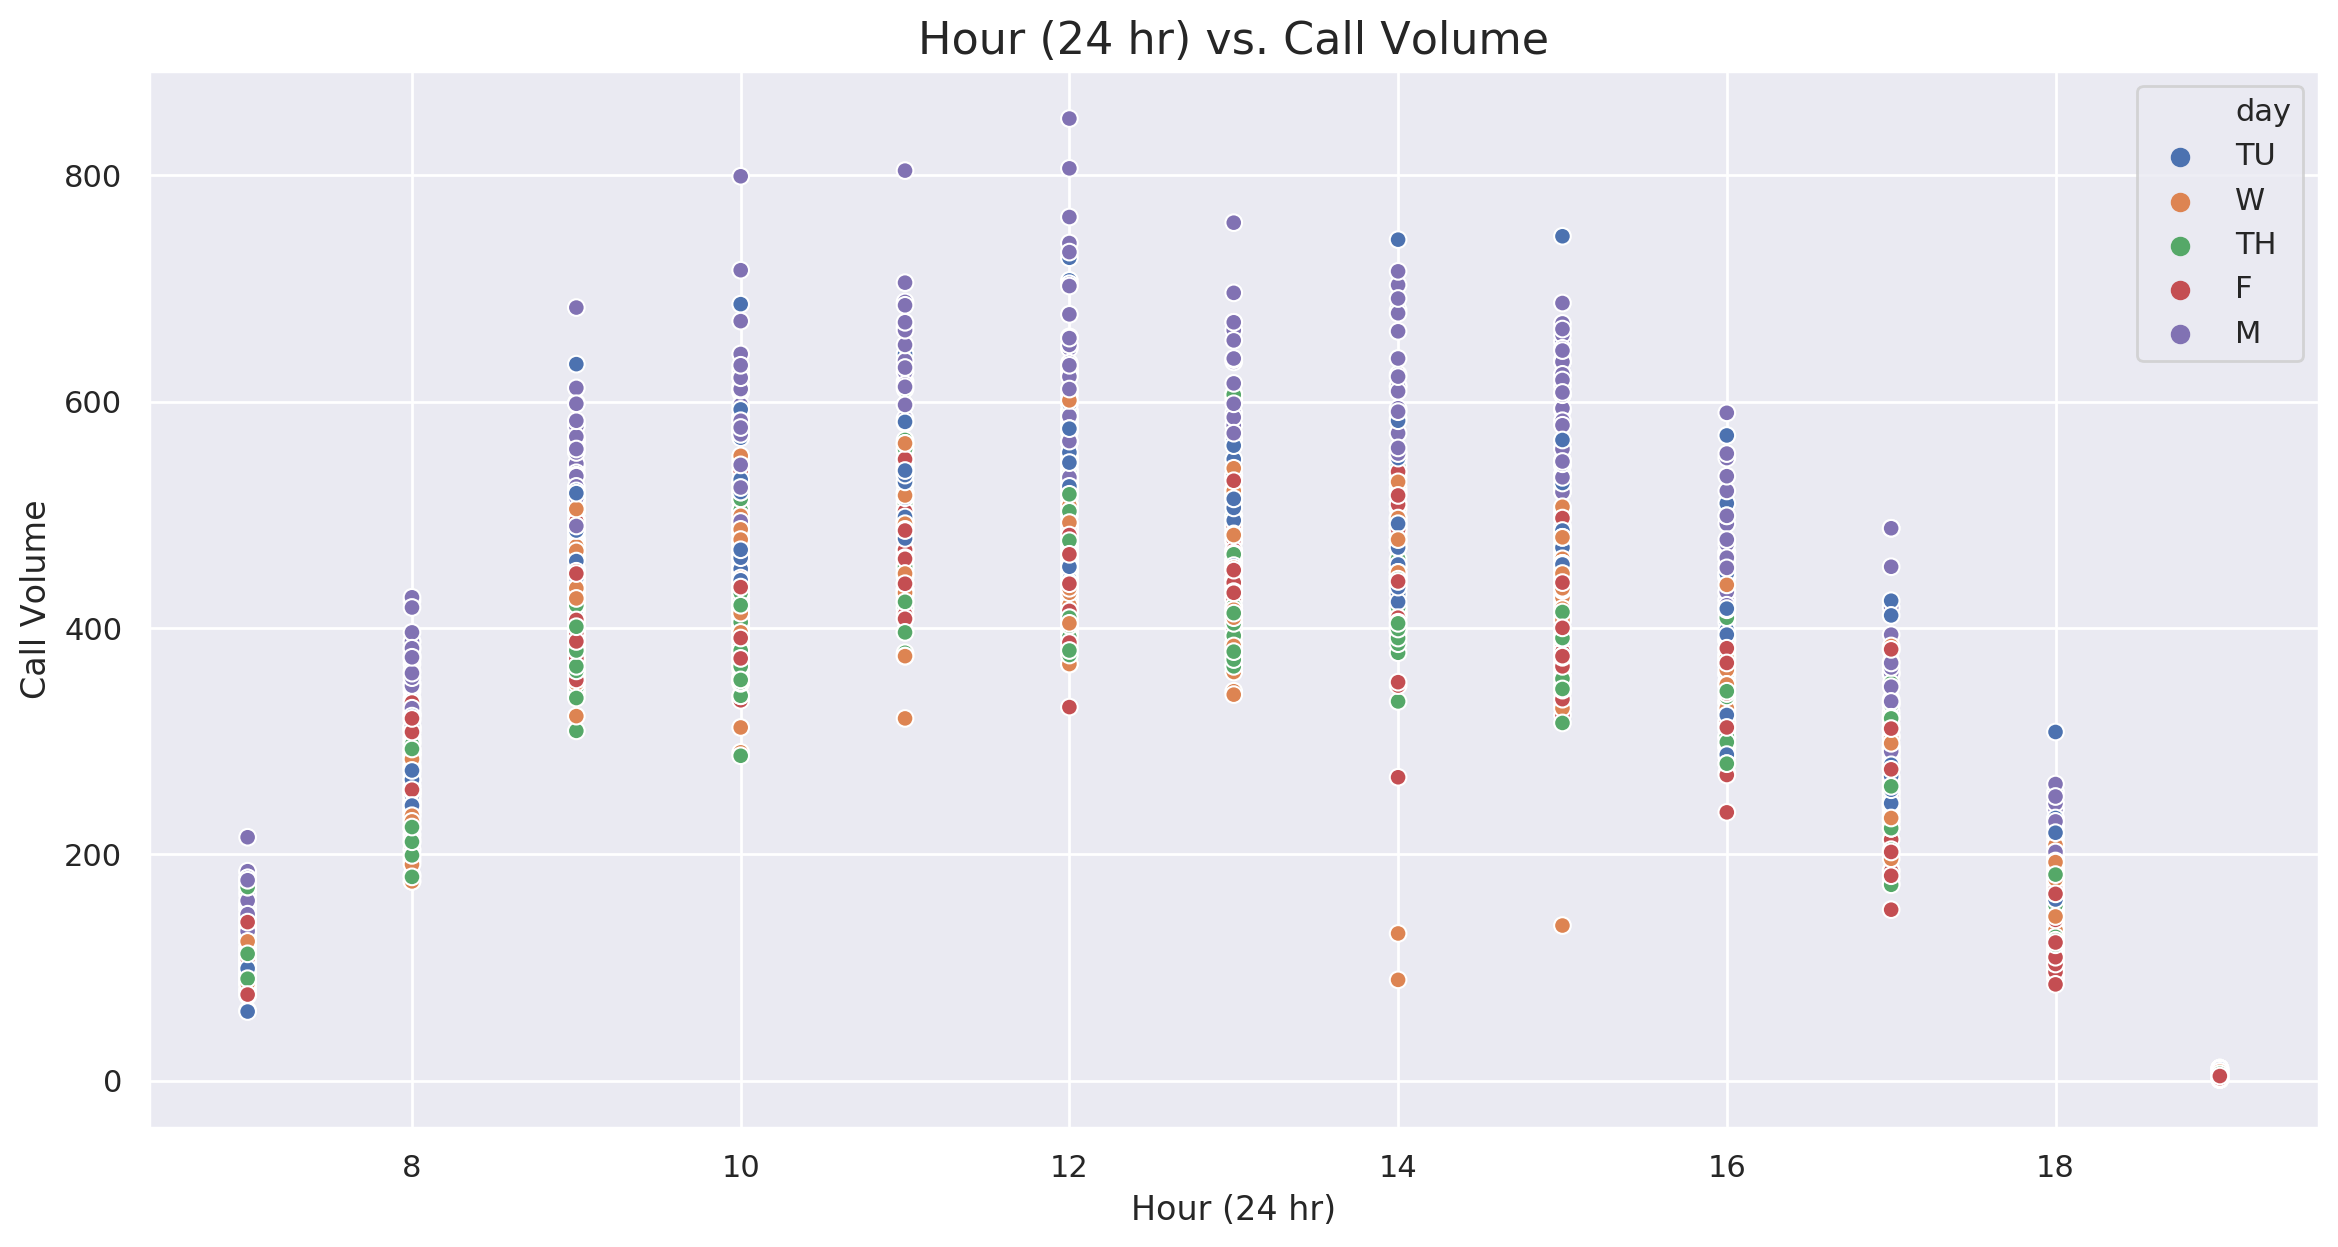

In [17]:
fig, ax = plt.subplots(figsize=(14,7), dpi=200)
sns.scatterplot(x="hour", y="CV", hue="day", data=train)
plt.title('Hour (24 hr) vs. Call Volume', fontsize=16)
ax.set_xlabel('Hour (24 hr)')
ax.set_ylabel('Call Volume')
plt.show()

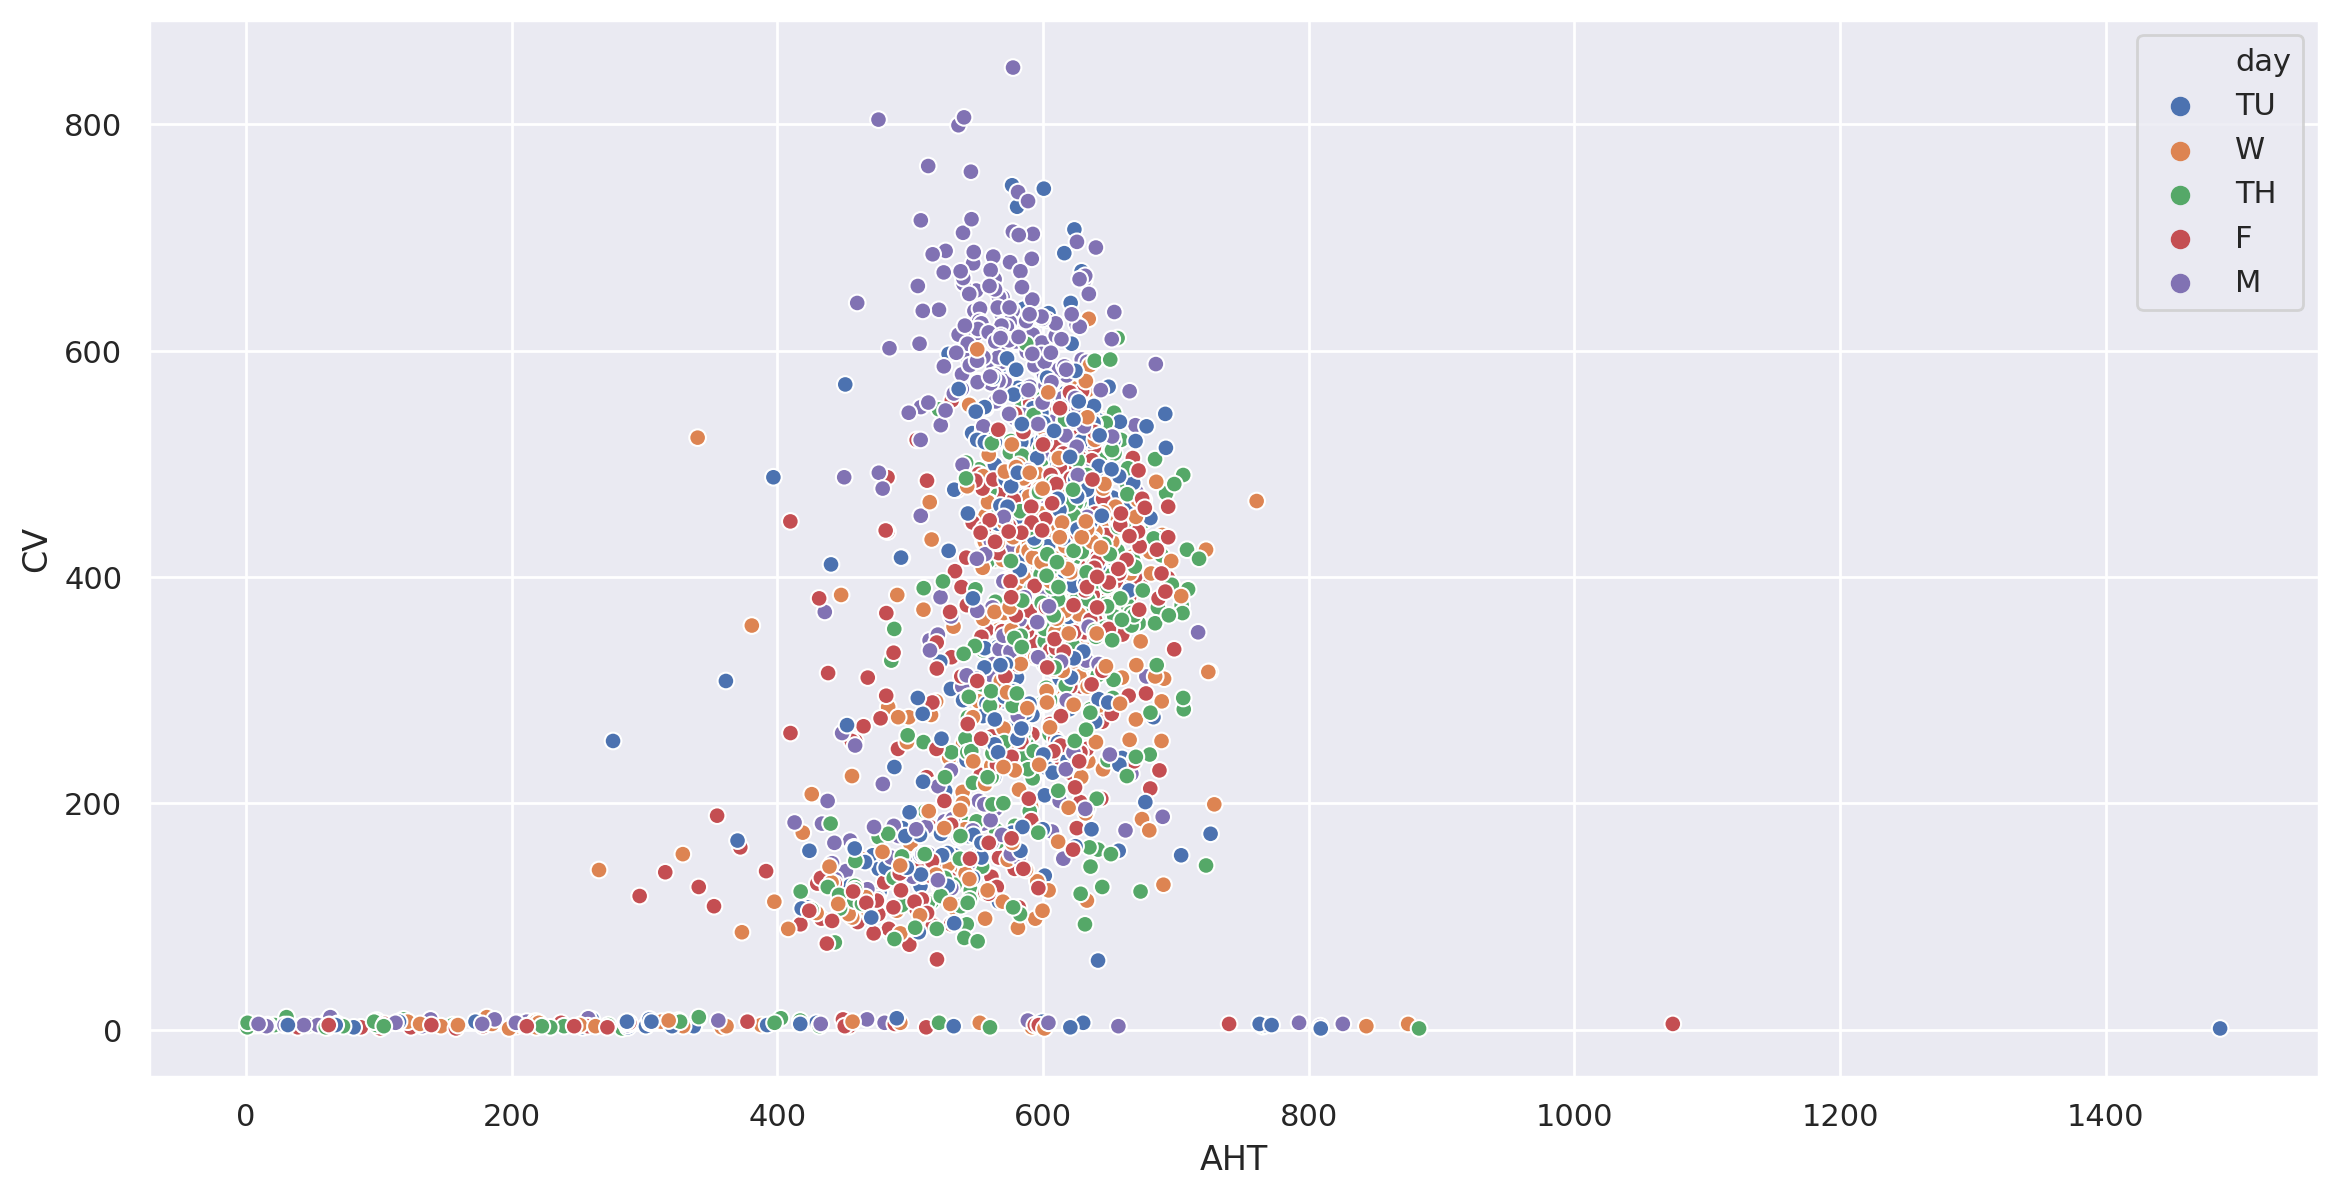

In [18]:
fig, ax = plt.subplots(figsize=(14,7), dpi=200)
sns.scatterplot(x='AHT', y='CV', data=train, hue='day')
plt.show()

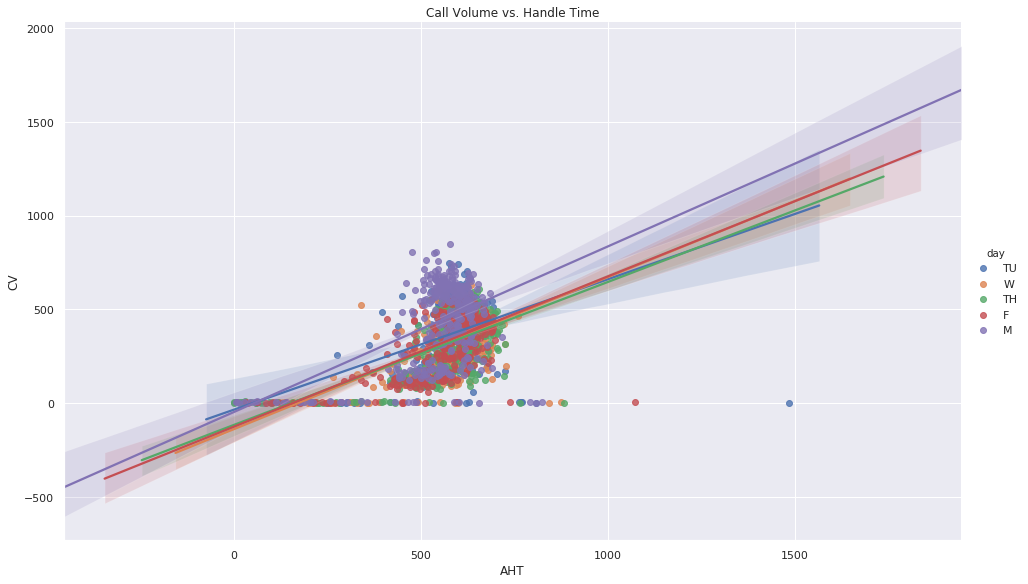

In [19]:
sns.lmplot(x='AHT', y='CV', data=train,
           fit_reg=True, hue='day', height=8, aspect=1.7)
plt.title('Call Volume vs. Handle Time')
plt.show()

In [20]:
# Output CSV to begin modeling
train.to_csv('../data/interim/02training.csv')